# Results pipeline
Here we combine the models trained in notebooks 2 and 3, for the pattern classifier and the inverse solvers, respectively, to construct an inverse solver which 1) identifies the pattern of vortices and 2) applies the corresponding inverse solver for the identified pattern. We then measure the accuracy of the results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N = 128
L = np.pi

x_grid = torch.linspace(-L/2, L/2, N+1)[:-1]
y_grid = torch.linspace(-L/2, L/2, N+1)[:-1]

Y, X = torch.meshgrid(y_grid, x_grid, indexing="ij")

X = X.to(device)
Y = Y.to(device)

# Rebuild and load trained models

In [2]:
# First introduce the classifier model.

classifier = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=5, padding=2, padding_mode="circular"),
    nn.Tanh(),

    nn.Conv2d(8, 16, kernel_size=5, padding=2, padding_mode="circular"),
    nn.Tanh(),

    nn.AvgPool2d(kernel_size=2),

    nn.Conv2d(16, 32, kernel_size=5, padding=2, padding_mode="circular"),
    nn.Tanh(),

    nn.AvgPool2d(kernel_size=2),

    nn.Conv2d(32, 64, kernel_size=5, padding=2, padding_mode="circular"),
    nn.Tanh(),

    nn.AdaptiveAvgPool2d((8, 8)),

    nn.Flatten(),

    nn.Linear(64 * 8 * 8, 64),
    nn.Tanh(),

    nn.Linear(64, 4),
).to(device)

# Now define the class for inverting evolutions of pair-type configurations of vortices
class PairInverseNet(nn.Module):
    def __init__(self, L=np.pi, amp_max=15.0, sigma_min=0.10, sigma_max=0.16):
        super().__init__()

        self.L = L
        self.amp_max = amp_max
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

        self.model = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(16, 32, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(64, 64, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (N // 16)**2, 128),
            nn.Tanh(),
            nn.Linear(128, 8) # Returns 4 * 2 = 8 parameter slots: 4 parameters ((x0, y0), amplitude, sigma), for each of 2 vortices
        )

    def forward(self, x):
        z = self.model(x)
        raw = self.head(z)
        
        raw = raw.view(-1, 2, 4)

        raw_xy = raw[:, :, 0:2]
        raw_amp = raw[:, :, 2]
        raw_sigma = raw[:, :, 3]

        xy = (self.L / 2) * torch.tanh(raw_xy)

        amp = self.amp_max * torch.tanh(raw_amp)

        sigma = self.sigma_min + (self.sigma_max - self.sigma_min) * torch.sigmoid(raw_sigma)

        params = torch.zeros_like(raw)
        params[:, :, 0:2] = xy
        params[:, :, 2] = amp
        params[:, :, 3] = sigma

        return params

# Now introduce the class for inverting triple-type configurations of vortices.
class TripleInverseNet(nn.Module):
    def __init__(self, L=np.pi, amp_max=15.0, sigma_min=0.10, sigma_max=0.16):
        super().__init__()

        self.L = L
        self.amp_max = amp_max
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

        self.model = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(16, 32, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(32, 64, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),

            nn.Conv2d(64, 64, kernel_size=5, padding=2, padding_mode="circular"),
            nn.ReLU(),
            nn.AvgPool2d(2),
            
            nn.Flatten(),
            nn.Linear(64 * (N // 16)**2, 128),
            nn.Tanh(),
            nn.Linear(128, 12) # Returns 4 * 3 = 12 parameter slots: 4 parameters ((x0, y0), amplitude, sigma), for each of 3 vortices
        )

    def forward(self, x):
        raw = self.model(x)
        raw = raw.view(-1, 3, 4)

        raw_xy = raw[:, :, 0:2]
        raw_amp = raw[:, :, 2]
        raw_sigma = raw[:, :, 3]

        xy = (self.L / 2) * torch.tanh(raw_xy)

        amp = self.amp_max * torch.tanh(raw_amp)

        sigma = self.sigma_min + (self.sigma_max - self.sigma_min) * torch.sigmoid(raw_sigma)

        params = torch.zeros_like(raw)
        params[:, :, 0:2] = xy
        params[:, :, 2] = amp
        params[:, :, 3] = sigma

        return params

In [3]:
# Now load the saved weights from the models trained in notebooks 2 and 3.

classifier_state = torch.load("pattern_classifier.pt", map_location=device)
classifier.load_state_dict(classifier_state)
classifier.eval()

checkpoint_sp = torch.load("inverse_same_pair.pt", map_location=device)
model_sp = PairInverseNet().to(device)
model_sp.load_state_dict(checkpoint_sp["model_state_dict"])
input_scale_sp = checkpoint_sp["input_scale"]
model_sp.eval()

checkpoint_op = torch.load("inverse_opposite_pair.pt", map_location=device)
model_op = PairInverseNet().to(device)
model_op.load_state_dict(checkpoint_op["model_state_dict"])
input_scale_op = checkpoint_op["input_scale"]
model_op.eval()

checkpoint_st = torch.load("inverse_same_triple.pt", map_location=device)
model_st = TripleInverseNet().to(device)
model_st.load_state_dict(checkpoint_st["model_state_dict"])
input_scale_st = checkpoint_st["input_scale"]
model_st.eval()

checkpoint_mt = torch.load("inverse_mixed_triple.pt", map_location=device)
model_mt = TripleInverseNet().to(device)
model_mt.load_state_dict(checkpoint_mt["model_state_dict"])
input_scale_mt = checkpoint_mt["input_scale"]
model_mt.eval()

TripleInverseNet(
  (model): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), padding_mode=circular)
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), padding_mode=circular)
    (4): ReLU()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), padding_mode=circular)
    (7): ReLU()
    (8): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (9): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), padding_mode=circular)
    (10): ReLU()
    (11): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=4096, out_features=128, bias=True)
    (14): Tanh()
    (15): Linear(in_features=128, out_features=12, bias=True)
  )
)

# Load pregenerated data for model evaluation

In [4]:
same_pair_data = np.load("vortex_same_sign_pair_1000_aug.npz")
opposite_pair_data = np.load("vortex_opposite_sign_pair_1000_aug.npz")
same_triple_data = np.load("vortex_same_sign_triple_1000_aug.npz")
mixed_triple_data = np.load("vortex_mixed_sign_triple_1000_aug.npz")

# Evaluating the models on the data
Now that we have loaded the models and data (vorticity distributions at a later time), we now demonstrate how the models can be used to make a prediction for the initial vorticity distribution for each sample in the loaded data.

The basic breakdown is as follows:

The classifier model will analyze the vorticity distribution at a later time, and predict the class for the initial vorticity distribution, whether it be a) a pair of nearby vortices of the same sign, b) a pair of nearby vortices of opposite signs, c) a cluster of three vortices all of the same sign, or d) a cluster of three vortices of mixed signs.

Meanwhile, for the case of each class a), b), c), d), we have trained a special model for inverting the forward-in-time evolution to predict what the initial vorticity distribution was for a given later-in-time vorticity distribution.

We will combine these by first running the classifier model on a sample to predict the class to which it corresponds, then route that sample to the appropriate model for inverting the time evolution for that class. This allows us to reconstruct the original vorticity field for samples of any of the four types.

# Helper functions

In [5]:
def render_gaussian_vortices(params, X, Y, L):
    x0 = params[:, :, 0]
    y0 = params[:, :, 1]
    amp = params[:, :, 2]
    sigma = params[:, :, 3]

    theta_x = 2 * torch.pi * (X[None, None, :, :] - x0[:, :, None, None]) / L
    theta_y = 2 * torch.pi * (Y[None, None, :, :] - y0[:, :, None, None]) / L

    sigma_theta = (2 * torch.pi / L) * sigma[:, :, None, None]

    exponent = (-2.0 + torch.cos(theta_x) + torch.cos(theta_y)) / (sigma_theta**2)

    vortices = amp[:, :, None, None] * torch.exp(exponent)

    omega = vortices.sum(dim=1)

    return omega

id_to_label = {
    0: "same_sign_pair",
    1: "opposite_sign_pair",
    2: "same_sign_triple",
    3: "mixed_sign_triple"
}

def invert_evolution_batch(omega_batch):

    omega_batch = torch.as_tensor(omega_batch, dtype=torch.float32, device=device)

    # Add the one-channel dimension
    omega_batch = omega_batch[:, None, :, :]

    classifier.eval()
    model_sp.eval()
    model_op.eval()
    model_st.eval()
    model_mt.eval()

    with torch.no_grad():
        logits = classifier(omega_batch)
        predicted_ids = logits.argmax(dim=1)

        batch_size = omega_batch.shape[0]

        omega0_pred = torch.empty(batch_size, N, N, dtype=torch.float32, device=device)

        for class_id in range(4):
            class_mask = predicted_ids == class_id

            # Skip this inverse model if no samples received this class.
            if not class_mask.any():
                continue

            omega_class = omega_batch[class_mask]
            pattern_type = id_to_label[class_id]

            if pattern_type == "same_sign_pair":
                params = model_sp(omega_class / input_scale_sp)

            elif pattern_type == "opposite_sign_pair":
                params = model_op(omega_class / input_scale_op)

            elif pattern_type == "same_sign_triple":
                params = model_st(omega_class / input_scale_st)

            elif pattern_type == "mixed_sign_triple":
                params = model_mt(omega_class / input_scale_mt)

            omega0_class = render_gaussian_vortices(params, X, Y, L)

            # Put these reconstructed fields back into their
            # original positions in the batch.
            omega0_pred[class_mask] = omega0_class

    predicted_labels = [id_to_label[class_id] for class_id in predicted_ids.cpu().tolist()]

    return omega0_pred, predicted_labels

def invert_evolution(omega):

    omega_batch = np.asarray(omega)[None, :, :]

    omega0_batch, predicted_labels = invert_evolution_batch(omega_batch)

    omega0_pred = omega0_batch[0]
    predicted_label = predicted_labels[0]

    return omega0_pred, predicted_label

def relative_error(omega0_true, omega0_pred):
    omega0_true = torch.as_tensor(omega0_true, dtype=omega0_pred.dtype, device=omega0_pred.device)
    omega0_pred = omega0_pred.squeeze(0)

    error = omega0_pred - omega0_true
    error_L2_norm2 = torch.sum(error**2).item()
    true_L2_norm2 = torch.sum(omega0_true**2).item()
    return (error_L2_norm2 / true_L2_norm2)**0.5

# Single example pipeline for each class
Now we evaluate the models on a single example taken from the loaded dataset of each class: same sign vortex pair, opposite sign vortex pair, same sign cluster of three vortices, and mixed sign cluster of three vortices. By plotting a handful of inputs and outputs we will get a general idea whether our proposed method yields reasonable predictions.

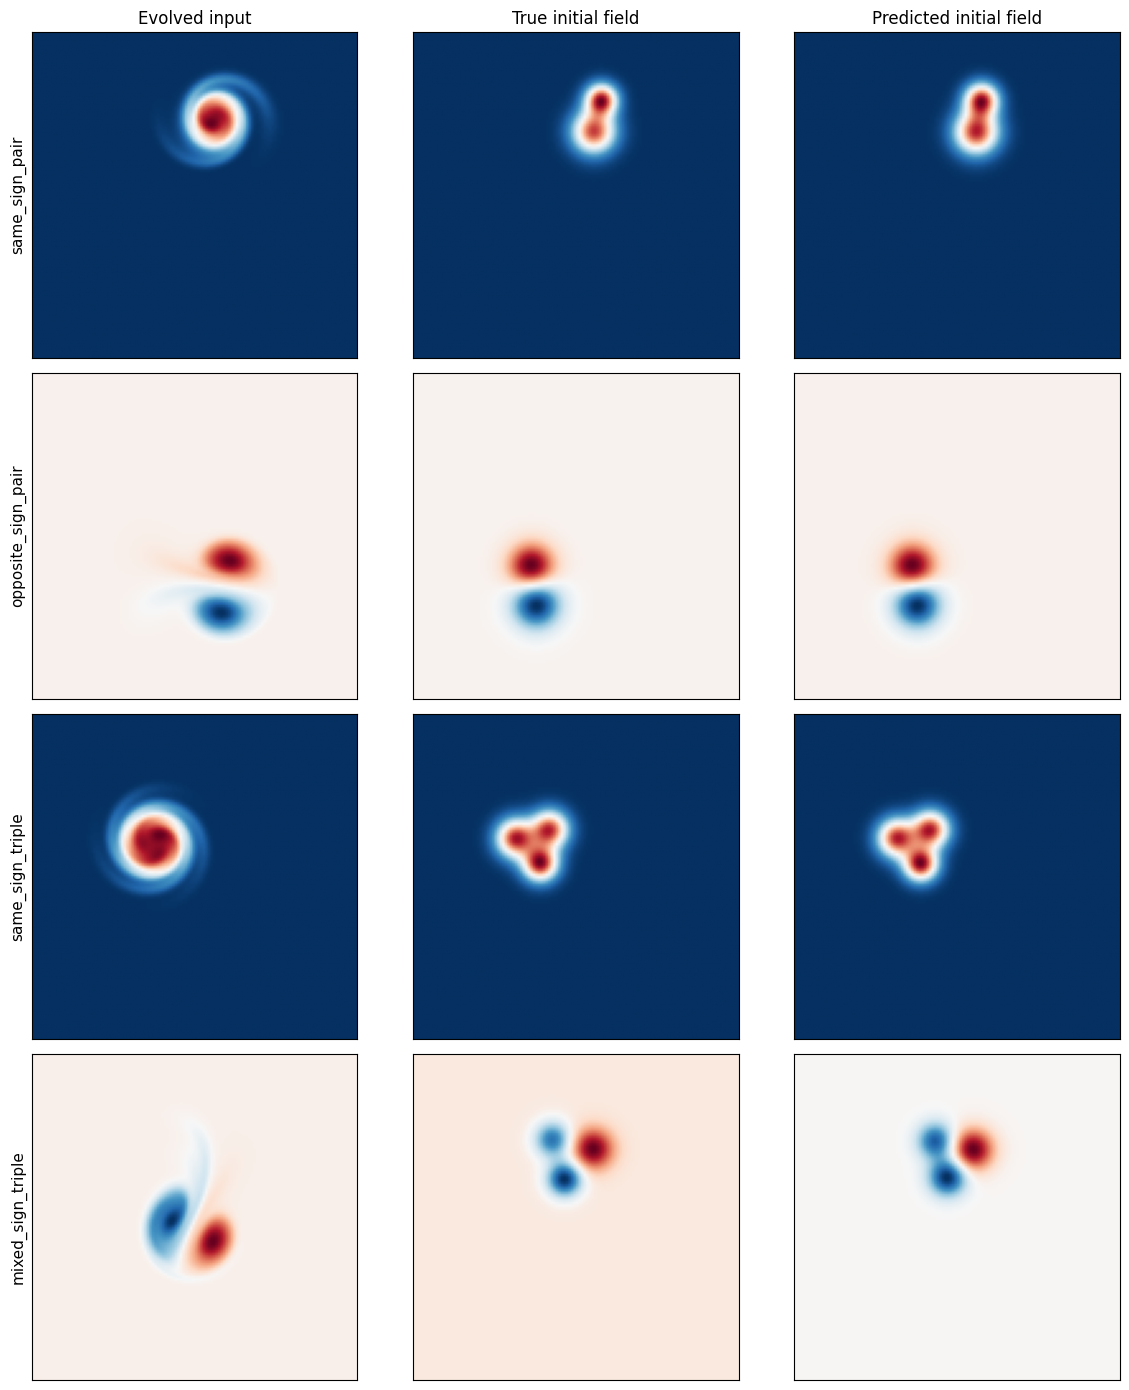

In [6]:
labeled_data = {
    "same_sign_pair": same_pair_data,
    "opposite_sign_pair": opposite_pair_data,
    "same_sign_triple": same_triple_data,
    "mixed_sign_triple": mixed_triple_data
}

sample_index = 0

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 14))

for row, (label, data) in enumerate(labeled_data.items()):
    omegaT_true = data["omegaT"][sample_index]
    omega0_true = data["omega0"][sample_index]

    omega0_pred, _ = invert_evolution(omegaT_true)  # Here we apply the function which takes in the later-time vorticity
                                                    # and uses the models to predict the initial vorticity.

    omega0_pred_np = omega0_pred.squeeze().cpu().numpy()

    fields = [omegaT_true, omega0_true, omega0_pred_np]

    titles = ["Evolved input", "True initial field", "Predicted initial field"]

    for col in range(3):
        axes[row, col].imshow(fields[col], origin="lower", cmap="RdBu_r")

        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

        if row == 0:
            axes[row, col].set_title(titles[col])

    axes[row, 0].set_ylabel(label, fontsize=11)

plt.tight_layout()
plt.show()

As we can see, the predicted initial vortex fields visually match the true initial vortex fields for each example quite well.

Now, we perform a more quantitative measure of accuracy by calculating the relative $L^2$ error for each example shown above, that is, the ratio of the size (the $L^2$ norm) of the predictive error to the size (again, the $L^2$ norm) of the true initial field for each example.

In [7]:
for (label, data) in labeled_data.items():
    omegaT = data["omegaT"][sample_index]
    omega0_true = data["omega0"][sample_index]

    omega0_pred, _ = invert_evolution(omegaT)

    rel_error = relative_error(omega0_true, omega0_pred)

    print(f"Relative L2 error for {label} example: {rel_error:.4f}")

Relative L2 error for same_sign_pair example: 0.0700
Relative L2 error for opposite_sign_pair example: 0.0169
Relative L2 error for same_sign_triple example: 0.0301
Relative L2 error for mixed_sign_triple example: 0.1202


These $L^2$ errors are very reasonable, rounding to 7% error for the same sign pair, 2% error for the opposite sign pair, 3% error for the same sign triple, and 12% error for the mixed sign triple, suggesting, again, that the predicted initial vortex distributions are close to the true ones.

# Batch evaluation
Now we will run through the full set of 4000 examples, comparing the corresponding predictions for the initial vortex fields to the true initial fields. We produce a list which records for each example vortex distribution, in particular, 1) the true initial distribution type (same sign pair, opposite sign pair, etc.), 2) the predicted initial distribution type, 3) whether the type classification succeeded, and 4) the relative error between the predicted initial field and the true initial field.

In [8]:
def relative_errors_batch(omega0_true, omega0_pred):

    omega0_true = torch.as_tensor(omega0_true, dtype=torch.float32, device=device)

    error = omega0_pred - omega0_true

    # Sum over the two spatial dimensions, separately for each sample.
    error_L2_norm_sq = torch.sum(error**2, dim=(1, 2))
    true_L2_norm_sq = torch.sum(omega0_true**2, dim=(1, 2))

    return torch.sqrt(error_L2_norm_sq / true_L2_norm_sq)

batch_results = []

batch_size = 64

for true_label, data in labeled_data.items():

    omegaT_all = data["omegaT"]
    omega0_true_all = data["omega0"]

    num_samples = len(omegaT_all)

    for batch_start in range(0, num_samples, batch_size):
        batch_end = batch_start + batch_size

        omegaT_batch = omegaT_all[batch_start:batch_end]
        omega0_true_batch = omega0_true_all[batch_start:batch_end]

        omega0_pred_batch, predicted_labels = (invert_evolution_batch(omegaT_batch)) # Here we apply the function which uses the models to predict
                                                                                     # initial vorticities from later-time vorticities (in batches).

        rel_errors = relative_errors_batch(omega0_true_batch, omega0_pred_batch)

        rel_errors = rel_errors.cpu().tolist()

        for batch_index, (predicted_label, rel_error) in enumerate(zip(predicted_labels, rel_errors)):
            sample_index = batch_start + batch_index

            batch_results.append(
                {
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "correct_classification": predicted_label == true_label,
                    "relative_error": rel_error,
                    "sample_index": sample_index
                }
            )

    print(f"finished: {true_label}")

finished: same_sign_pair
finished: opposite_sign_pair
finished: same_sign_triple
finished: mixed_sign_triple


# Evaluation results

## Overall reconstruction accuracy

In [10]:
results_df = pd.DataFrame(batch_results)

print(f"Mean relative L2 error over all results: {results_df['relative_error'].mean()}")
print("Mean relative L2 error for each type of vortex distribution:")
results_df.groupby("true_label")["relative_error"].mean()

Mean relative L2 error over all results: 0.08382947852369398
Mean relative L2 error for each type of vortex distribution:


true_label
mixed_sign_triple     0.127357
opposite_sign_pair    0.029966
same_sign_pair        0.072553
same_sign_triple      0.105441
Name: relative_error, dtype: float64

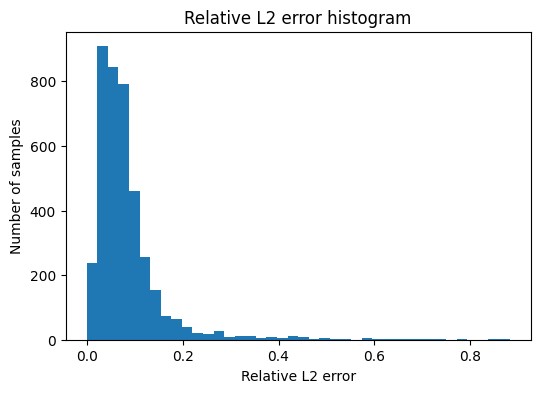

In [11]:
plt.figure(figsize=(6,4))

plt.hist(results_df["relative_error"], bins=40, range=(0, results_df["relative_error"].max()))
plt.xlabel("Relative L2 error")
plt.ylabel("Number of samples")
plt.title("Relative L2 error histogram")

plt.show()

## Reconstruction error by vortex class

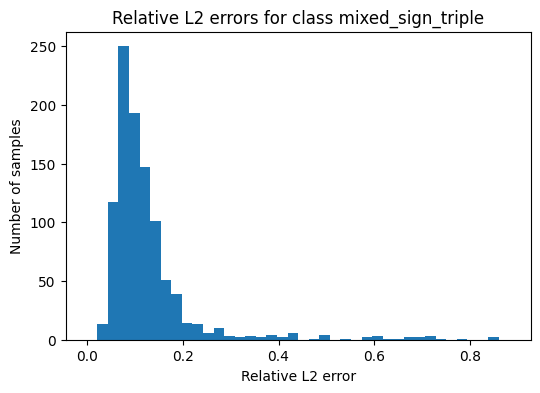

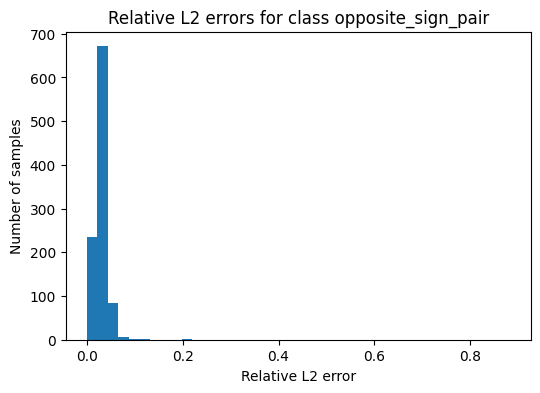

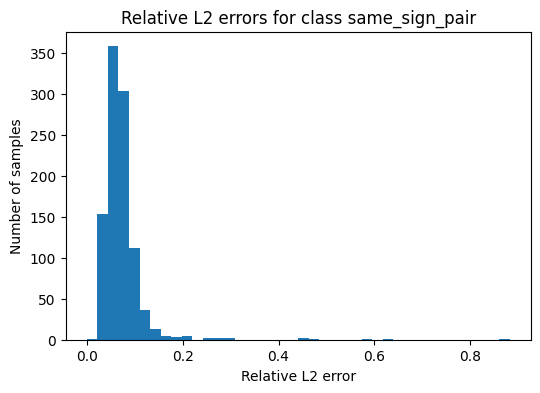

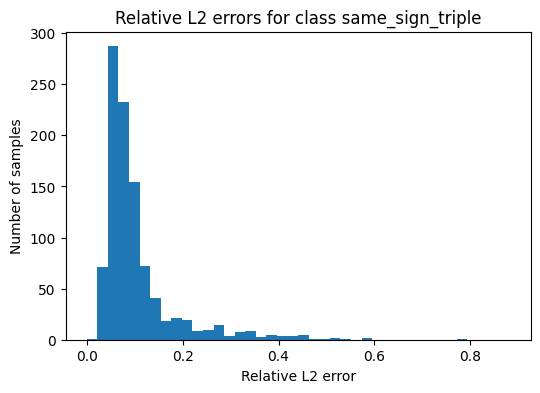

In [12]:
grouped_results = results_df.groupby("true_label")

for label, group_df in grouped_results:
    plt.figure(figsize=(6,4))

    plt.hist(group_df["relative_error"], bins=40, range=(0, results_df["relative_error"].max()))
    plt.xlabel("Relative L2 error")
    plt.ylabel("Number of samples")
    plt.title(f"Relative L2 errors for class {label}")

    plt.show()

### Tail errors

In [13]:
results_df.groupby("true_label")["relative_error"].quantile([0.50, 0.90, 0.95, 0.99]).unstack()

,0.50,0.90,0.95,0.99
true_label,,,,
mixed_sign_triple,0.102220,0.189198,0.275612,0.666998
opposite_sign_pair,0.027742,0.043693,0.049664,0.064282
same_sign_pair,0.065618,0.102553,0.121418,0.263011
same_sign_triple,0.078424,0.198611,0.284455,0.449314


## Classification performance and effect of classification error

In [14]:
results_df.groupby("correct_classification")["relative_error"].agg(["count", "mean", "median"])

,count,mean,median
correct_classification,,,
False,3,0.593497,0.507237
True,3997,0.083447,0.066244


In [15]:
confusion_matrix = pd.crosstab(results_df["true_label"], results_df["predicted_label"])

confusion_matrix

predicted_label,mixed_sign_triple,opposite_sign_pair,same_sign_pair,same_sign_triple
true_label,,,,
mixed_sign_triple,999,1,0,0
opposite_sign_pair,0,1000,0,0
same_sign_pair,0,0,1000,0
same_sign_triple,0,0,2,998


Let us look at the mean, median, standard deviation, and maximum errors across all samples, including those for which the classification model misidentified the pattern type.

In [16]:
results_df.groupby("true_label")["relative_error"].agg(["mean", "median", "std", "max"])

,mean,median,std,max
true_label,,,,
mixed_sign_triple,0.127357,0.102220,0.100785,0.854061
opposite_sign_pair,0.029966,0.027742,0.012692,0.210131
same_sign_pair,0.072553,0.065618,0.051566,0.881954
same_sign_triple,0.105441,0.078424,0.084919,0.782831


Now, we shall compare to the analogous error measurements when we exclude the misclassified samples.

In [17]:
correct_results = results_df[results_df["correct_classification"]]

correct_results.groupby("true_label")["relative_error"].agg(["mean", "median", "std", "max"])

,mean,median,std,max
true_label,,,,
mixed_sign_triple,0.126994,0.102159,0.100177,0.854061
opposite_sign_pair,0.029966,0.027742,0.012692,0.210131
same_sign_pair,0.072553,0.065618,0.051566,0.881954
same_sign_triple,0.104360,0.078370,0.081255,0.581883


Observe that the summary statistics remain largely unchanged. This is to be expected for the mean, median, and standard deviation of the error, because the number of misclassifications is extremely small (only 3 out of 4000).

### Effect of misclassification on worst case errors

Note that the maximum error remained exactly the same for the opposite sign pairs, same sign pairs, and mixed sign triples, whereas it changed for the same sign triples. We already know the error should be the same for the same sign pairs and opposite sign pairs, because none of these samples were misclassified, and so we are computing numbers from exactly the same data as in the previous table for these.

On the other hand, one example was misclassified for the mixed sign triples and two were misclassified for the same sign triples. Since the max error became lower when we removed misclassified examples for the same sign triples, we know misclassification led to the largest error in reconstruction among all such samples. This is not surprising, because the model tried to reconstruct the initial state as a completely different vorticity distribution type.

Meanwhile, since the max error is the same for the mixed sign triple before and after removing the misclassified sample, the misclassification *did not* result in the greatest error for the mixed sign triples. Despite misclassification, the second part of the algorithm managed to come up with something slightly better than the true worst reconstruction. Thus classification errors are *not the only source of extreme reconstruction errors*.

## Failure case analysis

In [18]:
misclassified_results = results_df[~results_df["correct_classification"]]

misclassified_results

,true_label,predicted_label,correct_classification,relative_error,sample_index
2360,same_sign_triple,same_sign_pair,False,0.782831,360
2520,same_sign_triple,same_sign_pair,False,0.507237,520
3501,mixed_sign_triple,opposite_sign_pair,False,0.490424,501


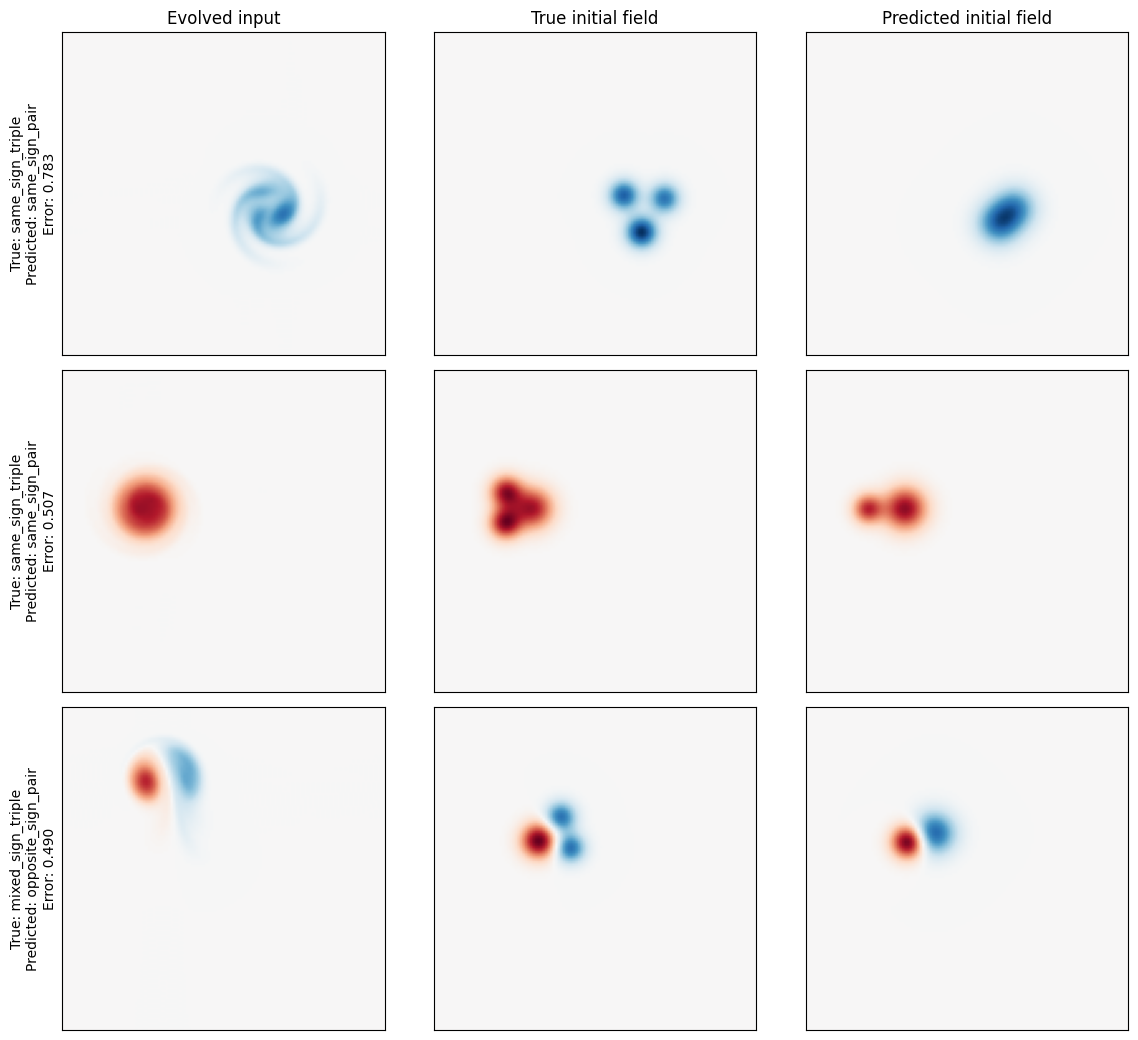

In [19]:
misclassified_results = results_df[~results_df["correct_classification"]]

fig, axes = plt.subplots(
    nrows=len(misclassified_results),
    ncols=3,
    figsize=(12, 3.5 * len(misclassified_results))
)

titles = ["Evolved input", "True initial field", "Predicted initial field"]

for row, (_, result) in enumerate(misclassified_results.iterrows()):
    true_label = result["true_label"]
    predicted_label = result["predicted_label"]
    sample_index = int(result["sample_index"])

    data = labeled_data[true_label]

    omegaT = data["omegaT"][sample_index]
    omega0_true = data["omega0"][sample_index]

    omega0_pred, _ = invert_evolution(omegaT)
    omega0_pred = omega0_pred.cpu().numpy()

    fields = [omegaT, omega0_true, omega0_pred]

    # Use the same color scale across the three panels in this row.
    vmax = max(np.abs(field).max() for field in fields)

    for col, field in enumerate(fields):
        axes[row, col].imshow(field, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

        if row == 0:
            axes[row, col].set_title(titles[col])

    axes[row, 0].set_ylabel(
        f"True: {true_label}\n"
        f"Predicted: {predicted_label}\n"
        f"Error: {result['relative_error']:.3f}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [20]:
correct_results = results_df[results_df["correct_classification"]]

high_error_results = correct_results.nlargest(10, "relative_error").reset_index(drop=True)

high_error_results[["true_label", "sample_index", "relative_error"]]

,true_label,sample_index,relative_error
0,same_sign_pair,155,0.881954
1,mixed_sign_triple,251,0.854061
2,mixed_sign_triple,398,0.841604
3,mixed_sign_triple,244,0.776972
4,mixed_sign_triple,884,0.748955
5,mixed_sign_triple,368,0.717386
6,mixed_sign_triple,329,0.712388
7,mixed_sign_triple,922,0.708088
8,mixed_sign_triple,390,0.694769
9,mixed_sign_triple,879,0.687530


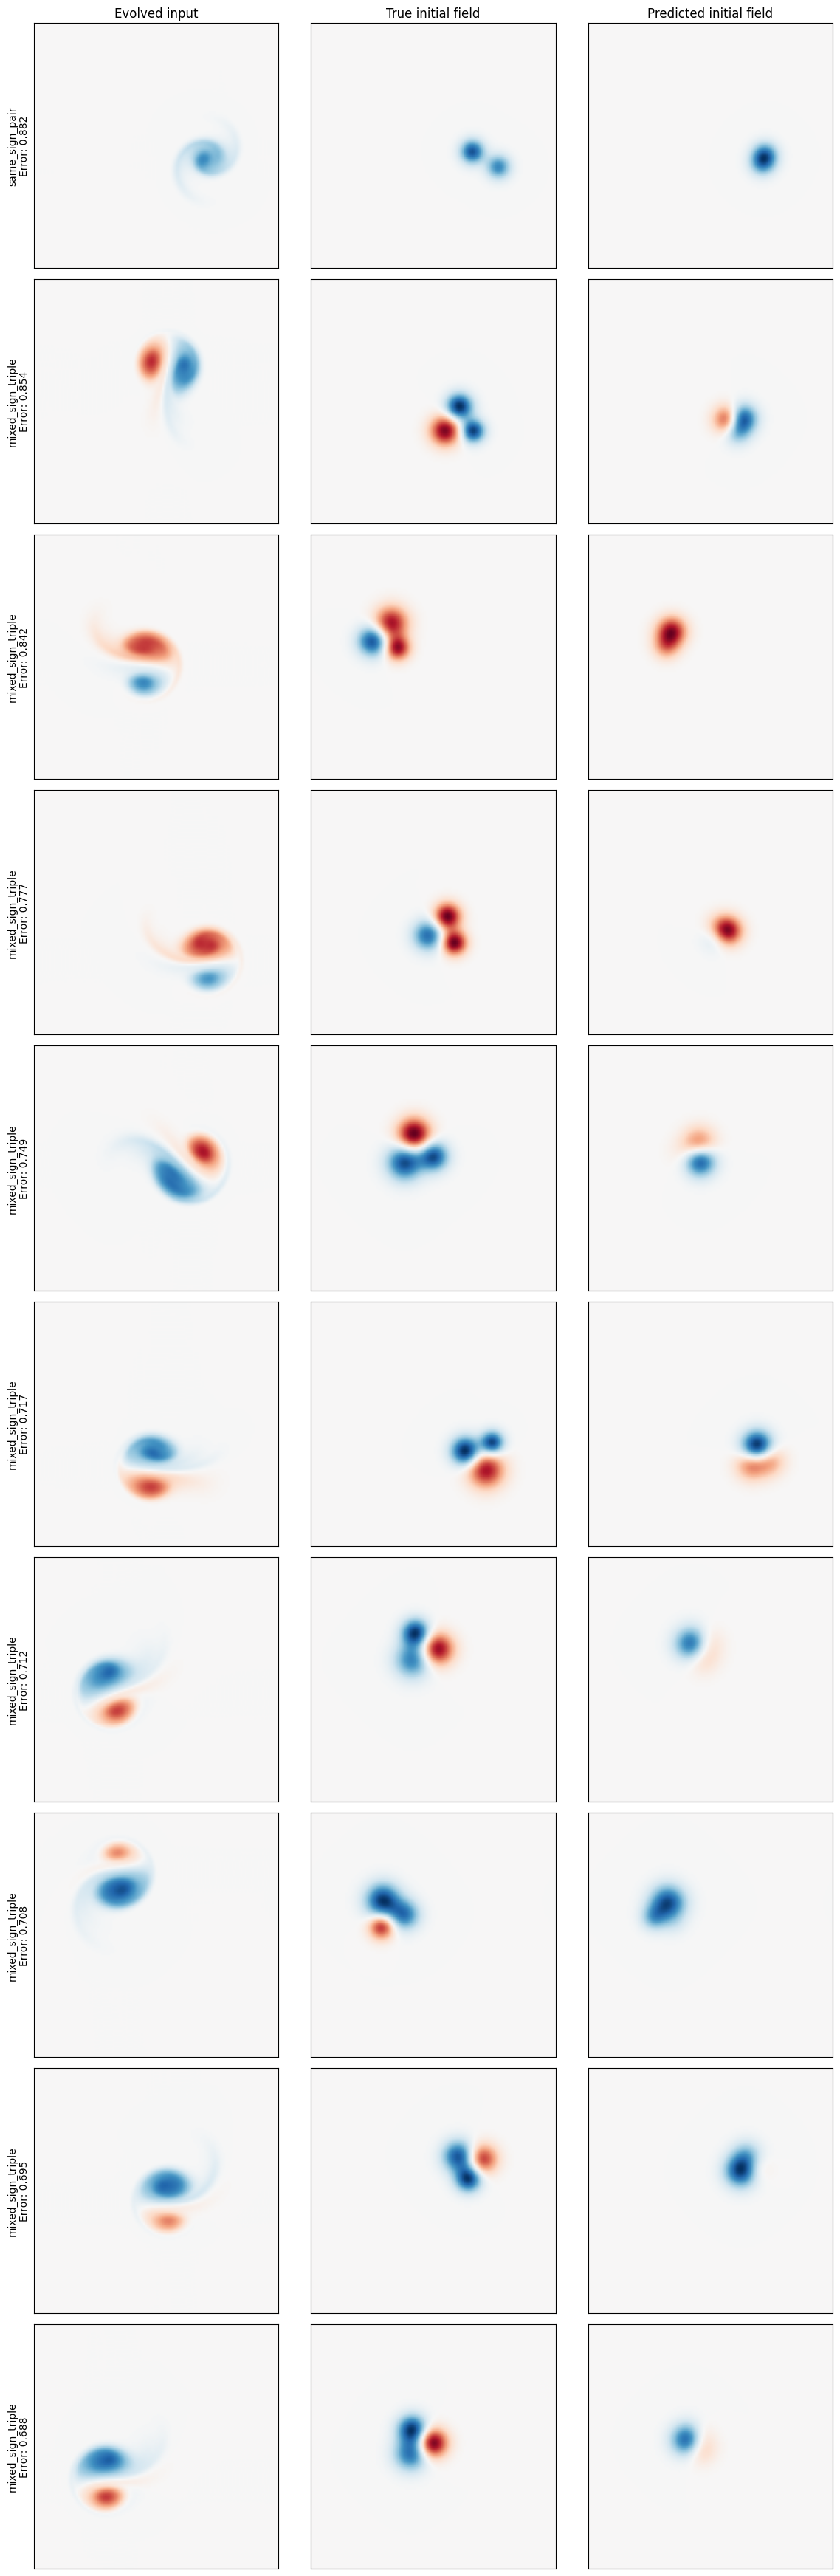

In [21]:
fig, axes = plt.subplots(nrows=len(high_error_results), ncols=3, figsize=(12, 3.5*len(high_error_results)))

titles = ["Evolved input", "True initial field", "Predicted initial field"]

for row, (_, result) in enumerate(high_error_results.iterrows()):

    true_label = result["true_label"]
    sample_index = int(result["sample_index"])

    data = labeled_data[true_label]

    omegaT = data["omegaT"][sample_index]
    omega0_true = data["omega0"][sample_index]

    omega0_pred, _ = invert_evolution(omegaT)
    omega0_pred = omega0_pred.cpu().numpy()

    fields = [omegaT, omega0_true, omega0_pred]

    vmax = max(np.abs(field).max() for field in fields)

    for col, field in enumerate(fields):
        axes[row, col].imshow(field, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)

        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

        if row == 0:
            axes[row, col].set_title(titles[col])

    axes[row, 0].set_ylabel(
        f"{true_label}\n"
        f"Error: {result['relative_error']:.3f}"
    )

plt.tight_layout()
plt.show()

### Qualitative analysis of high-error reconstructions

Inspection of the largest reconstruction errors among correctly classified samples suggests a recurring failure mode. In most of the high error cases, the inferred vortex configuration essentially collapses to a single dominant vortex blob, or something close to one. This can occur through vortices being placed very close together, or, for mixed sign triples, through two opposite sign vortices being placed at essentially the same location, causing them to cancel out and leave at most a faint trace next to the third vortex.

The corresponding evolved inputs often appear somewhat fainter and more symmetric than typical examples, although the present analysis does not establish whether these features are responsible for the reconstruction failures. More generally, the results suggest that some evolved configurations are difficult for the inverse model to resolve into distinct initial vortices, and the model instead generates an overly simplified vortex blob in these cases.

